# Customer Churn Prediction Using ML

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## Generate a Simulated Customer Churn Dataset

In [2]:
np.random.seed(42)
n = 2000

data = pd.DataFrame({
    'monthly_charges': np.random.randint(200, 1500, n),
    'contract_type': np.random.choice(['Monthly', 'One year', 'Two year'], n),
    'tech_support': np.random.choice(['Yes', 'No'], n),
    'tenure_months': np.random.randint(1, 72, n),
    'customer_support_calls': np.random.randint(0, 10, n),
    'internet_service': np.random.choice(['Fiber', 'DSL', 'None'], n)
})

# Create churn probability using business assumptions
prob = (
    0.2 +
    0.001 * (1500 - data['monthly_charges']) + 
    0.005 * data['customer_support_calls'] -
    0.003 * data['tenure_months']
)

prob = np.clip(prob, 0.01, 0.90)

data['churn'] = np.random.binomial(1, prob)

data.head()

,monthly_charges,contract_type,tech_support,tenure_months,customer_support_calls,internet_service,churn
0,1326,Two year,No,35,5,Fiber,0
1,1060,One year,No,22,3,DSL,0
2,1494,Monthly,Yes,65,8,DSL,0
3,1330,Two year,Yes,22,6,None,0
4,1295,Monthly,No,11,8,Fiber,1


## Encode Categorical Columns

In [3]:
data_encoded = pd.get_dummies(data, drop_first=True)
data_encoded.head()

,monthly_charges,tenure_months,customer_support_calls,churn,contract_type_One year,contract_type_Two year,tech_support_Yes,internet_service_Fiber,internet_service_None
0,1326,35,5,0,False,True,False,True,False
1,1060,22,3,0,True,False,False,False,False
2,1494,65,8,0,False,False,True,False,False
3,1330,22,6,0,False,True,True,False,True
4,1295,11,8,1,False,False,False,True,False


## Train / Test Split

In [4]:
X = data_encoded.drop('churn', axis=1)
y = data_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Handle Imbalanced Data using SMOTE

In [5]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## Train Models
### Logistic Regression Model

In [6]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = log_model.predict(X_test)

### Random Forest Model

In [7]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

### XGBoost Model

In [8]:
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)

## Model Evaluation

In [9]:
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.60      0.74      0.66       136
           1       0.85      0.74      0.79       264

    accuracy                           0.74       400
   macro avg       0.72      0.74      0.73       400
weighted avg       0.76      0.74      0.75       400

Random Forest:
               precision    recall  f1-score   support

           0       0.65      0.67      0.66       136
           1       0.83      0.82      0.82       264

    accuracy                           0.77       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.77      0.77      0.77       400

XGBoost:
               precision    recall  f1-score   support

           0       0.59      0.60      0.59       136
           1       0.79      0.79      0.79       264

    accuracy                           0.72       400
   macro avg       0.69      0.69      0.69       400
weighted avg       0.72   

## Confusion Matrix & ROC Curve

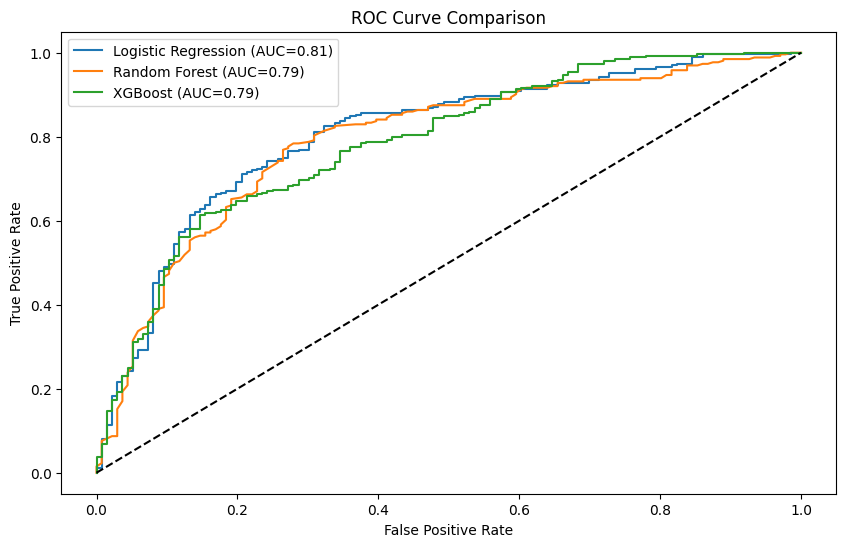

In [10]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Feature Importance (Business Insights)

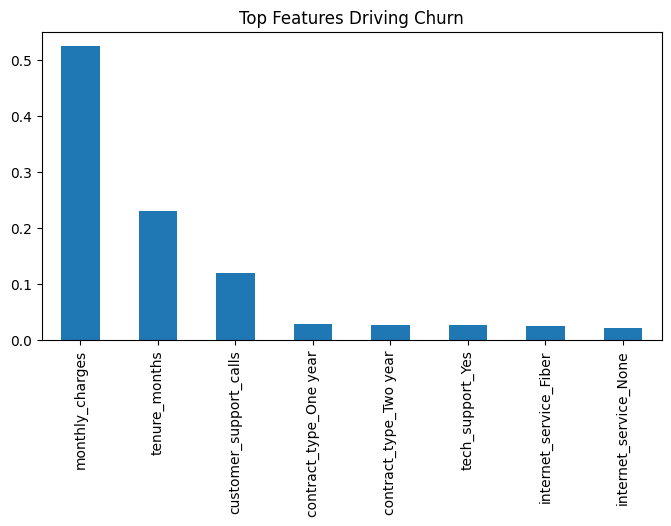

In [11]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importances.head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top Features Driving Churn")
plt.show()